# bt_03：真实 ETF 数据的 SMA 50/100/150/200/250 趋势跟踪参数区间测试

本 notebook 使用东方财富公开 K 线接口下载后的真实 ETF 前复权日线数据：`data/real_etf_daily_eastmoney.csv`。

目标不是挑一个收益最高的均线，而是检查 **50/100/150/200/250 这一段中长期 SMA 参数区间是否稳定**。


## 回测规则

- 标的：创业板ETF、沪深300ETF、国债ETF
- 数据：东方财富日线，前复权 `qfq`
- 信号：`close > SMA(window)` 视为趋势偏强
- 防未来函数：信号使用 `shift(1)`，即今天收盘确认信号，下一交易日才持仓
- 成本：每次仓位变化扣 `0.1%`，粗略代表手续费 + 滑点
- 对比：同时计算买入并持有基准


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path('../data/real_etf_daily_eastmoney.csv')
WINDOWS = [50, 100, 150, 200, 250]
FEE_RATE = 0.001
TRADING_DAYS = 252

pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=['date'], dtype={'symbol': 'string'})
df = df.sort_values(['symbol', 'date']).reset_index(drop=True)

print('rows:', len(df))
print('date range:', df['date'].min().date(), '->', df['date'].max().date())
df.groupby(['symbol', 'name']).agg(
    rows=('date', 'size'),
    start=('date', 'min'),
    end=('date', 'max'),
    first_close=('close', 'first'),
    last_close=('close', 'last'),
)


rows: 8348
date range: 2015-01-05 -> 2026-06-18


,,rows,start,end,first_close,last_close
symbol,name,,,,,
159915,创业板ETF易方达,2782,2015-01-05,2026-06-18,1.4240,4.2690
510300,沪深300ETF华泰柏瑞,2783,2015-01-05,2026-06-18,2.8890,4.9840
511010,国债ETF国泰,2783,2015-01-05,2026-06-18,99.6200,141.4310


In [3]:
def max_drawdown(equity: pd.Series) -> float:
    drawdown = equity / equity.cummax() - 1
    return float(drawdown.min())


def annualized_return(equity: pd.Series) -> float:
    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    years = (len(equity) - 1) / TRADING_DAYS
    return float((1 + total_return) ** (1 / years) - 1)


def annualized_sharpe(returns: pd.Series) -> float:
    returns = returns.dropna()
    std = returns.std(ddof=0)
    if std == 0 or np.isnan(std):
        return np.nan
    return float(returns.mean() / std * np.sqrt(TRADING_DAYS))


def calmar(ann_return: float, mdd: float) -> float:
    if mdd >= 0 or np.isnan(mdd):
        return np.nan
    return float(ann_return / abs(mdd))


In [4]:
rows = []
equity_curves = {}
benchmark_rows = []
benchmark_curves = {}

for (symbol, name), g in df.groupby(['symbol', 'name'], sort=True):
    g = g.sort_values('date').copy()
    close = g['close'].astype(float)
    asset_return = close.pct_change().fillna(0)
    buy_hold_equity = (1 + asset_return).cumprod()
    benchmark_curves[(symbol, name)] = pd.Series(buy_hold_equity.values, index=g['date'], name='buy_hold')
    bench_ann = annualized_return(buy_hold_equity)
    bench_mdd = max_drawdown(buy_hold_equity)
    benchmark_rows.append({
        'symbol': symbol,
        'name': name,
        'strategy': 'Buy & Hold',
        'total_return': float(buy_hold_equity.iloc[-1] - 1),
        'annualized_return': bench_ann,
        'max_drawdown': bench_mdd,
        'sharpe': annualized_sharpe(asset_return),
        'calmar': calmar(bench_ann, bench_mdd),
        'trades': 1,
        'time_in_market': 1.0,
    })

    for window in WINDOWS:
        sma = close.rolling(window).mean()
        raw_signal = close > sma
        position = raw_signal.shift(1).fillna(False).astype(float)
        trade = position.diff().abs().fillna(position.abs())
        strategy_return = position * asset_return - trade * FEE_RATE
        equity = (1 + strategy_return).cumprod()
        ann = annualized_return(equity)
        mdd = max_drawdown(equity)
        rows.append({
            'symbol': symbol,
            'name': name,
            'sma_window': window,
            'total_return': float(equity.iloc[-1] - 1),
            'annualized_return': ann,
            'max_drawdown': mdd,
            'sharpe': annualized_sharpe(strategy_return),
            'calmar': calmar(ann, mdd),
            'trades': int(trade.sum()),
            'time_in_market': float(position.mean()),
        })
        equity_curves[(symbol, name, window)] = pd.Series(equity.values, index=g['date'], name=f'SMA {window}')

result = pd.DataFrame(rows)
benchmark = pd.DataFrame(benchmark_rows)
result


,symbol,name,sma_window,total_return,annualized_return,max_drawdown,sharpe,calmar,trades,time_in_market
0,159915,创业板ETF易方达,50,2.0400,0.1060,-0.4734,0.5475,0.2239,173,0.4975
1,159915,创业板ETF易方达,100,-0.2099,-0.0211,-0.7236,0.0238,-0.0292,125,0.4684
2,159915,创业板ETF易方达,150,0.6188,0.0446,-0.5021,0.3089,0.0889,99,0.4637
3,159915,创业板ETF易方达,200,1.0523,0.0673,-0.4776,0.4057,0.1409,73,0.4464
4,159915,创业板ETF易方达,250,1.8788,0.1006,-0.3494,0.5580,0.2878,45,0.4094
5,510300,沪深300ETF华泰柏瑞,50,0.5638,0.0413,-0.3176,0.3287,0.1301,173,0.5329
6,510300,沪深300ETF华泰柏瑞,100,-0.1396,-0.0135,-0.4754,-0.0060,-0.0284,121,0.5347
7,510300,沪深300ETF华泰柏瑞,150,0.5549,0.0408,-0.4076,0.3429,0.1001,85,0.5271
8,510300,沪深300ETF华泰柏瑞,200,0.8138,0.0554,-0.2875,0.4313,0.1928,53,0.5350
9,510300,沪深300ETF华泰柏瑞,250,0.7818,0.0537,-0.3270,0.4222,0.1643,57,0.5264


In [5]:
display_cols = ['symbol', 'name', 'sma_window', 'total_return', 'annualized_return', 'max_drawdown', 'sharpe', 'calmar', 'trades', 'time_in_market']
display_result = result[display_cols].copy()
for col in ['total_return', 'annualized_return', 'max_drawdown', 'time_in_market']:
    display_result[col] = display_result[col].map(lambda x: f'{x:.2%}')
for col in ['sharpe', 'calmar']:
    display_result[col] = display_result[col].map(lambda x: f'{x:.3f}')
display_result


,symbol,name,sma_window,total_return,annualized_return,max_drawdown,sharpe,calmar,trades,time_in_market
0,159915,创业板ETF易方达,50,204.00%,10.60%,-47.34%,0.548,0.224,173,49.75%
1,159915,创业板ETF易方达,100,-20.99%,-2.11%,-72.36%,0.024,-0.029,125,46.84%
2,159915,创业板ETF易方达,150,61.88%,4.46%,-50.21%,0.309,0.089,99,46.37%
3,159915,创业板ETF易方达,200,105.23%,6.73%,-47.76%,0.406,0.141,73,44.64%
4,159915,创业板ETF易方达,250,187.88%,10.06%,-34.94%,0.558,0.288,45,40.94%
5,510300,沪深300ETF华泰柏瑞,50,56.38%,4.13%,-31.76%,0.329,0.130,173,53.29%
6,510300,沪深300ETF华泰柏瑞,100,-13.96%,-1.35%,-47.54%,-0.006,-0.028,121,53.47%
7,510300,沪深300ETF华泰柏瑞,150,55.49%,4.08%,-40.76%,0.343,0.100,85,52.71%
8,510300,沪深300ETF华泰柏瑞,200,81.38%,5.54%,-28.75%,0.431,0.193,53,53.50%
9,510300,沪深300ETF华泰柏瑞,250,78.18%,5.37%,-32.70%,0.422,0.164,57,52.64%


In [6]:
benchmark_display = benchmark.copy()
for col in ['total_return', 'annualized_return', 'max_drawdown', 'time_in_market']:
    benchmark_display[col] = benchmark_display[col].map(lambda x: f'{x:.2%}')
for col in ['sharpe', 'calmar']:
    benchmark_display[col] = benchmark_display[col].map(lambda x: f'{x:.3f}')
benchmark_display


,symbol,name,strategy,total_return,annualized_return,max_drawdown,sharpe,calmar,trades,time_in_market
0,159915,创业板ETF易方达,Buy & Hold,199.79%,10.46%,-69.58%,0.462,0.150,1,100.00%
1,510300,沪深300ETF华泰柏瑞,Buy & Hold,72.52%,5.06%,-52.97%,0.320,0.096,1,100.00%
2,511010,国债ETF国泰,Buy & Hold,41.97%,3.23%,-5.03%,1.356,0.641,1,100.00%


In [7]:
stability = result.groupby(['symbol', 'name']).agg(
    best_window=('sma_window', lambda s: int(result.loc[s.index].sort_values('total_return', ascending=False).iloc[0]['sma_window'])),
    best_total_return=('total_return', 'max'),
    worst_total_return=('total_return', 'min'),
    median_total_return=('total_return', 'median'),
    best_max_drawdown=('max_drawdown', 'max'),
    worst_max_drawdown=('max_drawdown', 'min'),
    min_trades=('trades', 'min'),
    max_trades=('trades', 'max'),
).reset_index()

stability_display = stability.copy()
for col in ['best_total_return', 'worst_total_return', 'median_total_return', 'best_max_drawdown', 'worst_max_drawdown']:
    stability_display[col] = stability_display[col].map(lambda x: f'{x:.2%}')
stability_display


,symbol,name,best_window,best_total_return,worst_total_return,median_total_return,best_max_drawdown,worst_max_drawdown,min_trades,max_trades
0,159915,创业板ETF易方达,50,204.00%,-20.99%,105.23%,-34.94%,-72.36%,45,173
1,510300,沪深300ETF华泰柏瑞,200,81.38%,-13.96%,56.38%,-28.75%,-47.54%,53,173
2,511010,国债ETF国泰,200,31.01%,16.96%,29.28%,-4.16%,-6.51%,15,131


C:\Users\yza\AppData\Local\Temp\ipykernel_19076\1501177412.py:14: UserWarning: Glyph 21019 (\N{CJK UNIFIED IDEOGRAPH-521B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yza\AppData\Local\Temp\ipykernel_19076\1501177412.py:14: UserWarning: Glyph 19994 (\N{CJK UNIFIED IDEOGRAPH-4E1A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yza\AppData\Local\Temp\ipykernel_19076\1501177412.py:14: UserWarning: Glyph 26495 (\N{CJK UNIFIED IDEOGRAPH-677F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yza\AppData\Local\Temp\ipykernel_19076\1501177412.py:14: UserWarning: Glyph 26131 (\N{CJK UNIFIED IDEOGRAPH-6613}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yza\AppData\Local\Temp\ipykernel_19076\1501177412.py:14: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yza\AppData\Local\Temp\ipykernel_19076\1501177412.py:14: UserWarning: Glyph 36798 (\N{CJK UNIFIE

D:\Quant\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 27818 (\N{CJK UNIFIED IDEOGRAPH-6CAA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
D:\Quant\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 28145 (\N{CJK UNIFIED IDEOGRAPH-6DF1}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
D:\Quant\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 21326 (\N{CJK UNIFIED IDEOGRAPH-534E}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
D:\Quant\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 27888 (\N{CJK UNIFIED IDEOGRAPH-6CF0}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
D:\Quant\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 26575 (\N{CJK UNIFIED IDEOGRAPH-67CF}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
D:\Quant\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 29790 (\N{CJK UNIFIED IDEOGRAPH-745

D:\Quant\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21019 (\N{CJK UNIFIED IDEOGRAPH-521B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Quant\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 19994 (\N{CJK UNIFIED IDEOGRAPH-4E1A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Quant\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26495 (\N{CJK UNIFIED IDEOGRAPH-677F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Quant\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26131 (\N{CJK UNIFIED IDEOGRAPH-6613}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Quant\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Qu

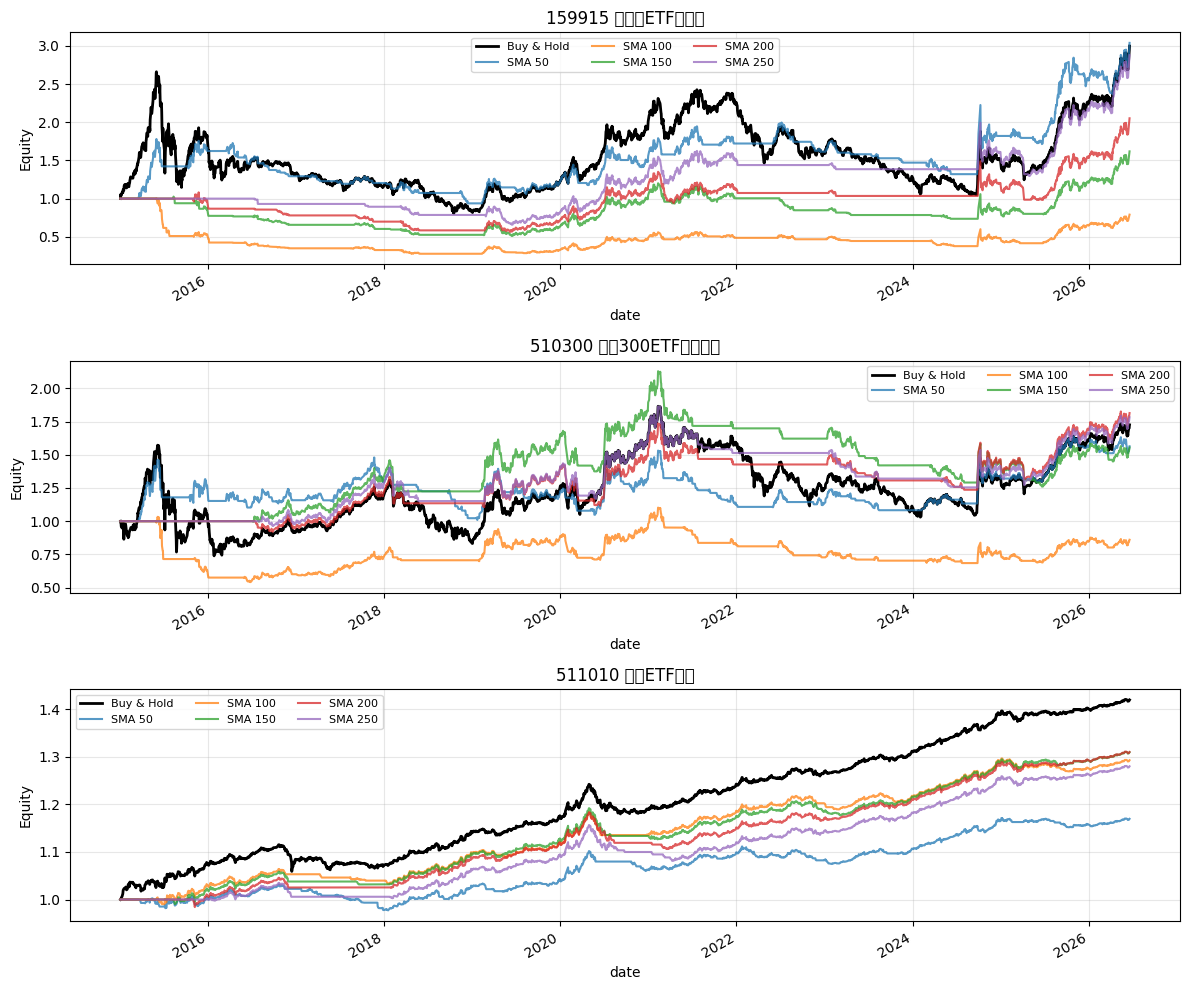

In [8]:
fig, axes = plt.subplots(len(benchmark_curves), 1, figsize=(12, 10), sharex=False)
if len(benchmark_curves) == 1:
    axes = [axes]

for ax, ((symbol, name), buy_hold) in zip(axes, benchmark_curves.items()):
    buy_hold.plot(ax=ax, label='Buy & Hold', linewidth=2, color='black')
    for window in WINDOWS:
        equity_curves[(symbol, name, window)].plot(ax=ax, label=f'SMA {window}', alpha=0.75)
    ax.set_title(f'{symbol} {name}')
    ax.set_ylabel('Equity')
    ax.legend(ncol=3, fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()


## 如何解读

1. 如果 50/100/150/200/250 多数窗口表现方向一致，说明参数区间相对稳定。
2. 如果只有一个窗口明显好，旁边窗口都差，要警惕参数过拟合。
3. 如果 SMA 收益低于买入并持有，但最大回撤显著下降，它可能是风险控制工具，而不是收益增强工具。
4. 如果交易次数很多、收益很薄，成本和滑点可能轻易吞掉结果。
